# Summary

This notebook explored the newly provided intrinsic neural timescale (INT) dataset.

The analyses verified:

- Dataset dimensions
- Variable structure
- Subject alignment with cortical thickness data
- Distribution of INT values
- Region-level summaries
- Missingness
- Quality of the processed measurements

The exploratory analysis indicates that the dataset is clean, aligned with the cortical thickness dataset, and suitable for downstream predictive modeling.

The next notebook will focus on using these INT measurements for four-class Alzheimer's disease prediction and comparing their predictive performance against cortical thickness.

In this notebook, I am just going to be opening up the INT data to get familiar with its structure and its contents.

In [10]:
#Load packages
library(tidyverse)
library(lubridate)
library(stringr)

#Check working directory
getwd()

[1] "/Users/andrescastellanos/Desktop/Summer_Research/AD_onboarding/R_analysis"

# Exploring the INT Dataset

This notebook explores the contents of the newly provided `.RData` file containing intrinsic neural timescale (INT) information.

The objective is to understand the structure of the dataset before performing any preprocessing or predictive modeling. Initial exploration includes identifying the objects stored in the file, examining variable names and data types, checking for missing values, and understanding how the INT measurements are organized.

## Step 1
Load packages

In [11]:
install.packages("skimr")
install.packages("janitor")


The downloaded binary packages are in
	/var/folders/wt/px8n7b_12jlcttxjqfd698y40000gn/T//Rtmp3FhOFi/downloaded_packages

The downloaded binary packages are in
	/var/folders/wt/px8n7b_12jlcttxjqfd698y40000gn/T//Rtmp3FhOFi/downloaded_packages


In [12]:
library(tidyverse)
library(skimr)
library(janitor)

In [13]:
#Check working directory
getwd()

#load data
load("../Data/ADNI_INT_CT_demo.RData")

[1] "/Users/andrescastellanos/Desktop/Summer_Research/AD_onboarding/R_analysis"

## Step 3: See What Objects Were Loaded

After loading the `.RData` file, the next step is to identify what object or objects were added to the R environment. Unlike a CSV file, an `.RData` file can contain one object or multiple objects, and the object names are not always obvious from the file name.

The `ls()` command lists all objects currently available in the R environment. This helps determine what dataset name should be inspected in the next step.

In [14]:
# ============================================================
# Step 3: See what objects were loaded
# ============================================================

ls()

[1] "baseline_demo"      "batch"              "ctmap_combat"      
 [4] "intmap_combat"      "label_ROI"          "n"                 
 [7] "object_summary"     "objects"            "p"                 
[10] "thickness_baseline"

## Step 4: Inspect Each Loaded Object

The `.RData` file contains several R objects rather than a single dataset. Before selecting a dataset for analysis, it is important to understand what each object represents.

For each object, I first inspect its class and dimensions. This helps determine whether the object is a data frame, matrix, vector, or another data structure, and provides an overview of its size before examining its contents in more detail.

In [15]:
# ============================================================
# Step 4: Inspect each loaded object
# ============================================================

objects <- ls()

object_summary <- data.frame(
  Object = objects,
  Class = sapply(objects, function(x) class(get(x))[1]),
  Rows = sapply(objects, function(x){
    obj <- get(x)
    if(is.data.frame(obj) || is.matrix(obj)) nrow(obj) else NA
  }),
  Columns = sapply(objects, function(x){
    obj <- get(x)
    if(is.data.frame(obj) || is.matrix(obj)) ncol(obj) else NA
  })
)

object_summary

,Object,Class,Rows,Columns
,<chr>,<chr>,<int>,<int>
baseline_demo,baseline_demo,spec_tbl_df,904,28
batch,batch,factor,NA,NA
ctmap_combat,ctmap_combat,matrix,68,904
intmap_combat,intmap_combat,matrix,84,904
label_ROI,label_ROI,spec_tbl_df,84,5
n,n,integer,NA,NA
object_summary,object_summary,data.frame,8,4
objects,objects,character,NA,NA
p,p,numeric,NA,NA


## Step 5: Explore the Baseline Demographic Dataset

The `baseline_demo` object appears to contain participant-level demographic and clinical information. Since every imaging measurement is associated with an individual participant, this dataset likely serves as the primary reference table for diagnosis, demographic variables, and subject identifiers.

Before examining the imaging matrices, it is important to understand the information contained within this demographic dataset.

In [16]:
# ============================================================
# Step 5: Explore baseline demographics
# ============================================================

class(baseline_demo)

dim(baseline_demo)

glimpse(baseline_demo)

[1] "spec_tbl_df" "tbl_df"      "tbl"         "data.frame"

[1] 904  28

Rows: 904
Columns: 28
$ subject     <chr> "002S0295X20110602", "002S0413X20110616", "002S0685X201107…
$ PTID        <chr> "002S0295", "002S0413", "002S0685", "002S0729", "002S1155"…
$ scandate    <chr> "6/2/2011", "6/16/2011", "7/8/2011", "8/16/2011", "12/22/2…
$ RID         <dbl> 295, 413, 685, 729, 1155, 1261, 1268, 1280, 2010, 2043, 20…
$ SITEID      <fct> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 27, 1, 1, 1, 1, 1, 1, 1, …
$ E4_combine  <dbl> 34, 33, 33, 34, 33, 33, 34, 34, 34, 34, 33, 33, 33, 33, 34…
$ E4_3grp     <chr> "e4", "33", "33", "e4", "33", "33", "e4", "e4", "e4", "e4"…
$ APOE4       <chr> "P", "N", "N", "P", "N", "N", "P", "P", "P", "P", "N", "N"…
$ PTGENDER    <fct> M, F, F, F, M, F, M, F, F, F, F, M, F, F, M, M, F, M, F, F…
$ PTDOBMM     <dbl> 6, 12, 11, 5, 1, 12, 5, 5, 7, 5, 4, 3, 8, 3, 10, 4, 10, 10…
$ PTDOBYY     <dbl> 1921, 1929, 1916, 1941, 1949, 1935, 1924, 1936, 1947, 1938…
$ PTHAND      <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ PTMARRY     <dbl

## Step 6: Inspect Diagnostic Groups

The `baseline_demo` dataset contains several diagnosis-related variables. The `group` column appears to define the four clinical groups needed for prediction: CN, MCI, Converter, and AD. Before merging imaging features, I first check the distribution of these groups and compare them with the original diagnosis and conversion-status variables.

In [17]:
# ============================================================
# Step 6: Inspect diagnostic groups
# ============================================================

baseline_demo %>%
  count(group)

baseline_demo %>%
  count(DX.new)

baseline_demo %>%
  count(ad_status)

group,n
<fct>,<int>
CN,476
MCI,262
Converter,57
AD,109


DX.new,n
<fct>,<int>
CN,480
Dement,109
MCI,315


ad_status,n
<chr>,<int>
Dement,57
No,592
NA,255


### Relationship Between Diagnosis Variables

The dataset contains multiple diagnosis-related variables. To understand how the final four-class outcome (`group`) was constructed, I compare it against the original baseline diagnosis (`DX.new`) and Alzheimer's conversion status (`ad_status`).

This helps verify how participants were assigned to the four prediction groups.

In [18]:
# ============================================================
# Step 6b: Compare diagnosis variables
# ============================================================

table(
  baseline_demo$DX.new,
  baseline_demo$group
)

table(
  baseline_demo$ad_status,
  baseline_demo$group,
  useNA = "ifany"
)

        
          CN MCI Converter  AD
  CN     476   0         4   0
  Dement   0   0         0 109
  MCI      0 262        53   0

        
          CN MCI Converter  AD
  Dement   0   0        57   0
  No     391 201         0   0
  <NA>    85  61         0 109

### Interpretation

The `group` variable is not simply the baseline diagnosis. Instead, it combines baseline clinical diagnosis (`DX.new`) with longitudinal Alzheimer's disease conversion information (`ad_status`) to create four clinically meaningful outcome groups.

Key observations:

- Participants diagnosed with dementia at baseline are assigned to the **AD** group.
- Participants who were cognitively normal or had MCI at baseline but later progressed to dementia are assigned to the **Converter** group.
- The majority of converters originated from the MCI group (53 of 57), while a small number converted directly from the cognitively normal group (4 of 57).
- Participants without evidence of future conversion remain in the CN or MCI groups.

This confirms that `group` is the appropriate outcome variable for the four-class prediction models developed later in the project.

## Step 7: Explore the Cortical Thickness Dataset

The object `thickness_baseline` contains the regional cortical thickness measurements for each participant.

Before examining the harmonized imaging data (`ctmap_combat` and `intmap_combat`), I first inspect the original cortical thickness dataset to understand its structure, variable names, and relationship to the demographic information explored previously.

This step also helps verify how the imaging features are organized before comparing them with the ComBat-harmonized datasets.

## Step 7: Explore the Cortical Thickness Dataset

After understanding the participant-level demographic and clinical information, the next step is to inspect the cortical thickness measurements.

The `thickness_baseline` object contains the regional cortical thickness values for each participant before harmonization. Examining its structure allows us to understand how the imaging features are organized, verify the number of cortical regions available, and compare this dataset with the harmonized cortical thickness (`ctmap_combat`) and intrinsic neural timescale (`intmap_combat`) datasets explored later.

The primary questions addressed in this step are:

- What is the structure of the cortical thickness dataset?
- How many cortical regions are measured?
- How are participants linked to the imaging measurements?
- Are these the same cortical thickness features used in the previous prediction analyses?

In [22]:
# ============================================================
# Step 7a: Inspect cortical thickness dataset
# ============================================================

class(thickness_baseline)

dim(thickness_baseline)

glimpse(thickness_baseline)

[1] "data.frame"

[1] 904  69

Rows: 904
Columns: 69
$ subject                               <chr> "002S0295X20110602", "002S0413X2…
$ lh_bankssts_thickness                 <dbl> 2.466, 2.614, 2.259, 2.287, 2.44…
$ lh_caudalanteriorcingulate_thickness  <dbl> 2.505, 2.561, 2.661, 3.139, 2.28…
$ lh_caudalmiddlefrontal_thickness      <dbl> 2.579, 2.582, 2.432, 2.603, 2.35…
$ lh_cuneus_thickness                   <dbl> 1.812, 1.908, 1.745, 1.761, 1.67…
$ lh_entorhinal_thickness               <dbl> 3.226, 3.141, 2.995, 2.106, 3.12…
$ lh_fusiform_thickness                 <dbl> 2.689, 2.593, 2.582, 2.664, 2.60…
$ lh_inferiorparietal_thickness         <dbl> 2.436, 2.402, 2.229, 2.084, 2.17…
$ lh_inferiortemporal_thickness         <dbl> 2.559, 2.674, 2.739, 2.644, 2.71…
$ lh_isthmuscingulate_thickness         <dbl> 2.139, 2.001, 2.259, 2.530, 2.10…
$ lh_lateraloccipital_thickness         <dbl> 2.101, 2.131, 2.000, 1.955, 2.10…
$ lh_lateralorbitofrontal_thickness     <dbl> 2.514, 2.711, 2.339, 2.624, 2.44…
$ lh_lingual_thick

In [23]:
# ============================================================
# Step 7b: Variable names
# ============================================================

names(thickness_baseline)

length(names(thickness_baseline))

[1] "subject"                              
 [2] "lh_bankssts_thickness"                
 [3] "lh_caudalanteriorcingulate_thickness" 
 [4] "lh_caudalmiddlefrontal_thickness"     
 [5] "lh_cuneus_thickness"                  
 [6] "lh_entorhinal_thickness"              
 [7] "lh_fusiform_thickness"                
 [8] "lh_inferiorparietal_thickness"        
 [9] "lh_inferiortemporal_thickness"        
[10] "lh_isthmuscingulate_thickness"        
[11] "lh_lateraloccipital_thickness"        
[12] "lh_lateralorbitofrontal_thickness"    
[13] "lh_lingual_thickness"                 
[14] "lh_medialorbitofrontal_thickness"     
[15] "lh_middletemporal_thickness"          
[16] "lh_parahippocampal_thickness"         
[17] "lh_paracentral_thickness"             
[18] "lh_parsopercularis_thickness"         
[19] "lh_parsorbitalis_thickness"           
[20] "lh_parstriangularis_thickness"        
[21] "lh_pericalcarine_thickness"           
[22] "lh_postcentral_thickness"             
[23] "lh_posteriorcingulate_thickness"      
[24] "lh_precentral_thickness"              
[25] "lh_precuneus_thickness"               
[26] "lh_rostralanteriorcingulate_thickness"
[27] "lh_rostralmiddlefrontal_thickness"    
[28] "lh_superiorfrontal_thickness"         
[29] "lh_superiorparietal_thickness"        
[30] "lh_superiortemporal_thickness"        
[31] "lh_supramarginal_thickness"           
[32] "lh_frontalpole_thickness"             
[33] "lh_temporalpole_thickness"            
[34] "lh_transversetemporal_thickness"      
[35] "lh_insula_thickness"                  
[36] "rh_bankssts_thickness"                
[37] "rh_caudalanteriorcingulate_thickness" 
[38] "rh_caudalmiddlefrontal_thickness"     
[39] "rh_cuneus_thickness"                  
[40] "rh_entorhinal_thickness"              
[41] "rh_fusiform_thickness"                
[42] "rh_inferiorparietal_thickness"        
[43] "rh_inferiortemporal_thickness"        
[44] "rh_isthmuscingulate_thickness"        
[45] "rh_lateraloccipital_thickness"        
[46] "rh_lateralorbitofrontal_thickness"    
[47] "rh_lingual_thickness"                 
[48] "rh_medialorbitofrontal_thickness"     
[49] "rh_middletemporal_thickness"          
[50] "rh_parahippocampal_thickness"         
[51] "rh_paracentral_thickness"             
[52] "rh_parsopercularis_thickness"         
[53] "rh_parsorbitalis_thickness"           
[54] "rh_parstriangularis_thickness"        
[55] "rh_pericalcarine_thickness"           
[56] "rh_postcentral_thickness"             
[57] "rh_posteriorcingulate_thickness"      
[58] "rh_precentral_thickness"              
[59] "rh_precuneus_thickness"               
[60] "rh_rostralanteriorcingulate_thickness"
[61] "rh_rostralmiddlefrontal_thickness"    
[62] "rh_superiorfrontal_thickness"         
[63] "rh_superiorparietal_thickness"        
[64] "rh_superiortemporal_thickness"        
[65] "rh_supramarginal_thickness"           
[66] "rh_frontalpole_thickness"             
[67] "rh_temporalpole_thickness"            
[68] "rh_transversetemporal_thickness"      
[69] "rh_insula_thickness"

[1] 69

In [24]:
# ============================================================
# Step 7c: Identify imaging variables
# ============================================================

# Subject identifier
names(thickness_baseline)[1]

# Cortical thickness variables
brain_regions <- names(thickness_baseline)[-1]

length(brain_regions)

head(brain_regions)

tail(brain_regions)

[1] "subject"

[1] 68

[1] "lh_bankssts_thickness"               
[2] "lh_caudalanteriorcingulate_thickness"
[3] "lh_caudalmiddlefrontal_thickness"    
[4] "lh_cuneus_thickness"                 
[5] "lh_entorhinal_thickness"             
[6] "lh_fusiform_thickness"

[1] "rh_superiortemporal_thickness"   "rh_supramarginal_thickness"     
[3] "rh_frontalpole_thickness"        "rh_temporalpole_thickness"      
[5] "rh_transversetemporal_thickness" "rh_insula_thickness"

## Step 8: Inspect the ComBat-Harmonized Cortical Thickness Matrix

The `ctmap_combat` object contains cortical thickness measurements after ComBat harmonization. ComBat is commonly used to reduce unwanted variability associated with acquisition site or scanner differences while preserving biologically meaningful variation.

The original `thickness_baseline` dataset is organized with participants as rows and cortical regions as columns. In contrast, `ctmap_combat` appears to be organized as a matrix with cortical regions as rows and participants as columns.

This step examines the structure, dimensions, row names, and column names of the harmonized cortical thickness matrix and checks whether its participant and region ordering corresponds to the original cortical thickness dataset.

In [26]:
# ============================================================
# Step 8a: Inspect harmonized cortical thickness matrix
# ============================================================

class(ctmap_combat)

dim(ctmap_combat)

rownames(ctmap_combat) |> head()

colnames(ctmap_combat) |> head()

[1] "matrix" "array"

[1]  68 904

[1] "lh_bankssts_thickness"               
[2] "lh_caudalanteriorcingulate_thickness"
[3] "lh_caudalmiddlefrontal_thickness"    
[4] "lh_cuneus_thickness"                 
[5] "lh_entorhinal_thickness"             
[6] "lh_fusiform_thickness"

[1] "X002S0295X20110602" "X002S0413X20110616" "X002S0685X20110708"
[4] "X002S0729X20110816" "X002S1155X20111222" "X002S1261X20110314"

### Step 8b: Verify Alignment Between Raw and Harmonized Thickness Data

Before using the harmonized cortical thickness matrix, I verify that its rows and columns correspond to the same cortical regions and participants as the original `thickness_baseline` dataset.

The harmonized matrix stores cortical regions as rows and participants as columns. Its participant column names include an additional leading `X`, which R automatically adds when a name begins with a number.

In [27]:
# ============================================================
# Step 8b: Verify alignment
# ============================================================

# Remove the leading X from matrix subject names
combat_subjects <- sub("^X", "", colnames(ctmap_combat))

# Compare participant order
all(combat_subjects == thickness_baseline$subject)

# Compare cortical region order
all(rownames(ctmap_combat) == names(thickness_baseline)[-1])

[1] TRUE

[1] TRUE

## Step 9: Explore the Intrinsic Neural Timescale (INT) Dataset

The `intmap_combat` object contains the harmonized intrinsic neural timescale (INT) measurements derived from resting-state fMRI.

Unlike cortical thickness, which measures structural changes in the cortex, INT is a functional imaging measure describing the temporal dynamics of neural activity within each brain region.

Before incorporating these features into future prediction models, it is important to understand the organization of the dataset, the number of brain regions represented, and how these measurements relate to the cortical thickness data explored previously.

In [28]:
# ============================================================
# Step 9a: Inspect INT dataset
# ============================================================

class(intmap_combat)

dim(intmap_combat)

rownames(intmap_combat) |> head()

colnames(intmap_combat) |> head()

[1] "matrix" "array"

[1]  84 904

NULL

[1] "X002S0295X20110602" "X002S0413X20110616" "X002S0685X20110708"
[4] "X002S0729X20110816" "X002S1155X20111222" "X002S1261X20110314"

## Step 10: Inspect INT Region Labels

The `intmap_combat` matrix contains 84 regional INT measurements, but the matrix itself does not include row names. The `label_ROI` object also contains 84 rows, suggesting that it provides the anatomical labels corresponding to each row of the INT matrix.

This step examines the ROI label table to determine how the 84 INT features are named and organized.

In [29]:
# ============================================================
# Step 10: Inspect ROI labels
# ============================================================

class(label_ROI)

dim(label_ROI)

glimpse(label_ROI)

head(label_ROI)

[1] "spec_tbl_df" "tbl_df"      "tbl"         "data.frame"

[1] 84  5

Rows: 84
Columns: 5
$ `#No.`    <dbl> 10, 11, 12, 13, 17, 18, 26, 28, 49, 50, 51, 52, 53, 54, 58, …
$ LabelName <chr> "Left-Thalamus", "Left-Caudate", "Left-Putamen", "Left-Palli…
$ R         <dbl> 0, 122, 236, 12, 220, 103, 255, 165, 0, 122, 236, 13, 220, 1…
$ G         <dbl> 118, 186, 13, 48, 216, 255, 165, 42, 118, 186, 13, 48, 216, …
$ B         <dbl> 14, 220, 176, 255, 20, 255, 0, 42, 14, 220, 176, 255, 20, 25…


#No.,LabelName,R,G,B
<dbl>,<chr>,<dbl>,<dbl>,<dbl>
10,Left-Thalamus,0,118,14
11,Left-Caudate,122,186,220
12,Left-Putamen,236,13,176
13,Left-Pallidum,12,48,255
17,Left-Hippocampus,220,216,20
18,Left-Amygdala,103,255,255


### Step 10b: Assign Anatomical Labels to the INT Matrix

The 84 rows of `label_ROI` correspond to the 84 rows of `intmap_combat`. The ROI table includes both cortical and subcortical brain structures, explaining why the INT dataset contains more regions than the 68-region cortical thickness dataset.

Because `intmap_combat` does not currently have row names, the anatomical labels from `label_ROI$LabelName` are assigned to the matrix. This makes each INT feature directly interpretable in later analyses.

In [30]:
# ============================================================
# Step 10b: Assign ROI names to INT matrix
# ============================================================

rownames(intmap_combat) <- label_ROI$LabelName

# Confirm labels were added
head(rownames(intmap_combat))

tail(rownames(intmap_combat))

# Verify that the number of labels matches the number of INT rows
length(rownames(intmap_combat)) == nrow(intmap_combat)

[1] "Left-Thalamus"    "Left-Caudate"     "Left-Putamen"     "Left-Pallidum"   
[5] "Left-Hippocampus" "Left-Amygdala"

[1] "ctx-rh-superiortemporal"   "ctx-rh-supramarginal"     
[3] "ctx-rh-frontalpole"        "ctx-rh-temporalpole"      
[5] "ctx-rh-transversetemporal" "ctx-rh-insula"

[1] TRUE

### Step 10c: Verify Participant Alignment

Before combining the INT measurements with demographic and diagnostic information, I verify that the participant columns in `intmap_combat` correspond exactly to the rows of `baseline_demo`.

The INT matrix column names contain an additional leading `X`, which R adds to identifiers that begin with a number. Removing this prefix allows the subject identifiers to be compared directly.

In [31]:
# ============================================================
# Step 10c: Verify participant alignment
# ============================================================

int_subjects <- sub("^X", "", colnames(intmap_combat))

all(int_subjects == baseline_demo$subject)

[1] TRUE

## Step 11: Exploratory Data Analysis of the INT Dataset

Now that the structure and participant alignment of the INT dataset have been verified, the next step is to explore the numerical properties of the measurements.

The goals of this exploratory analysis are to:

- Check for missing values.
- Examine the overall distribution of INT values.
- Summarize the range, center, and spread of the measurements.
- Identify potential outliers or unexpected values.
- Better understand the characteristics of the harmonized INT features before they are used in future prediction models.

This exploratory analysis helps verify data quality and provides intuition about the scale and variability of the intrinsic neural timescale measurements.

In [32]:
# ============================================================
# Step 11a: Overall summary statistics
# ============================================================

summary(as.vector(intmap_combat))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  0.873   1.516   1.656   1.703   1.839   3.996       4 

In [33]:
# ============================================================
# Step 11b: Missing values
# ============================================================

sum(is.na(intmap_combat))

mean(is.na(intmap_combat))

[1] 4

[1] 5.267594e-05

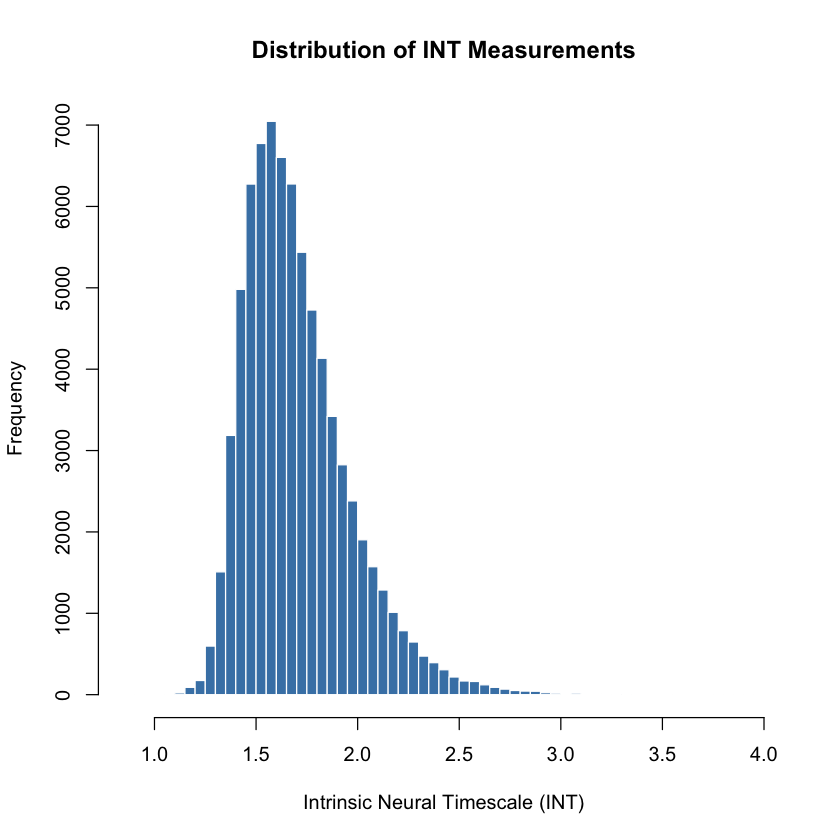

In [34]:
# ============================================================
# Step 11c: Distribution of INT values
# ============================================================

hist(
  as.vector(intmap_combat),
  breaks = 50,
  col = "steelblue",
  border = "white",
  main = "Distribution of INT Measurements",
  xlab = "Intrinsic Neural Timescale (INT)"
)

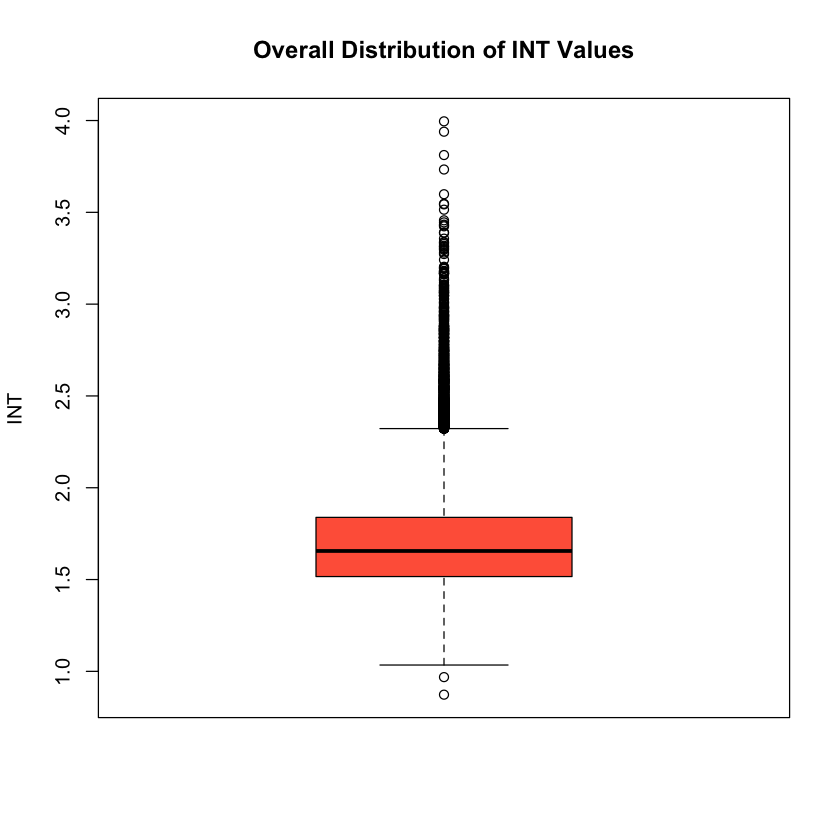

In [35]:
# ============================================================
# Step 11d: Overall boxplot
# ============================================================

boxplot(
  as.vector(intmap_combat),
  col = "tomato",
  main = "Overall Distribution of INT Values",
  ylab = "INT"
)

In [37]:
# ============================================================
# Step 11e: Mean and standard deviation
# ============================================================

mean(as.vector(intmap_combat))

sd(as.vector(intmap_combat))

[1] NA

[1] NA

### Step 11 Summary

The exploratory analysis suggests that the harmonized INT measurements are of high quality.

Key observations include:

- The distribution of INT values is unimodal with a slight right skew.
- The mean (1.703) is slightly larger than the median (1.656), consistent with the observed skewness.
- Only 4 missing values were identified across all 75,936 measurements (84 ROIs × 904 participants), indicating essentially complete data.
- The boxplot shows several high-value observations; however, these likely reflect natural biological variability across different brain regions rather than data quality issues.
- Overall, the INT dataset appears suitable for downstream statistical analysis and predictive modeling.

## Step 12: Region-Level Exploratory Analysis

After examining the overall distribution of the INT measurements, the next step is to summarize the measurements for each brain region individually.

Rather than pooling all 75,936 observations together, this analysis computes summary statistics for each of the 84 regions of interest (ROIs).

The objectives are to:

- Compute the average INT for every ROI.
- Identify regions with the highest and lowest intrinsic neural timescales.
- Examine variability across regions.
- Build intuition about which brain areas naturally exhibit longer or shorter temporal dynamics before comparing diagnostic groups.

In [38]:
# ============================================================
# Step 12a: Mean INT for each brain region
# ============================================================

region_mean_INT <- data.frame(
  Region = rownames(intmap_combat),
  Mean_INT = rowMeans(intmap_combat, na.rm = TRUE)
)

head(region_mean_INT)

,Region,Mean_INT
,<chr>,<dbl>
Left-Thalamus,Left-Thalamus,1.507322
Left-Caudate,Left-Caudate,1.521224
Left-Putamen,Left-Putamen,1.517741
Left-Pallidum,Left-Pallidum,1.453632
Left-Hippocampus,Left-Hippocampus,1.492866
Left-Amygdala,Left-Amygdala,1.524033


In [39]:
# ============================================================
# Step 12b: Highest average INT regions
# ============================================================

region_mean_INT <-
  region_mean_INT %>%
  arrange(desc(Mean_INT))

head(region_mean_INT, 10)

,Region,Mean_INT
,<chr>,<dbl>
ctx-lh-frontalpole,ctx-lh-frontalpole,2.026864
ctx-rh-frontalpole,ctx-rh-frontalpole,2.004506
ctx-rh-inferiorparietal,ctx-rh-inferiorparietal,1.954424
ctx-lh-inferiorparietal,ctx-lh-inferiorparietal,1.952018
ctx-lh-precuneus,ctx-lh-precuneus,1.938479
ctx-rh-lateraloccipital,ctx-rh-lateraloccipital,1.934621
ctx-lh-lateraloccipital,ctx-lh-lateraloccipital,1.921129
ctx-rh-precuneus,ctx-rh-precuneus,1.914650
ctx-rh-rostralmiddlefrontal,ctx-rh-rostralmiddlefrontal,1.894472


In [41]:
# Lowest average INT regions

tail(region_mean_INT,10)

,Region,Mean_INT
,<chr>,<dbl>
ctx-lh-parahippocampal,ctx-lh-parahippocampal,1.501149
Left-Accumbens-area,Left-Accumbens-area,1.501147
Right-Accumbens-area,Right-Accumbens-area,1.497611
Left-Hippocampus,Left-Hippocampus,1.492866
ctx-rh-parahippocampal,ctx-rh-parahippocampal,1.489678
Right-Hippocampus,Right-Hippocampus,1.489400
Right-Pallidum,Right-Pallidum,1.463707
Left-Pallidum,Left-Pallidum,1.453632
Right-VentralDC,Right-VentralDC,1.437378


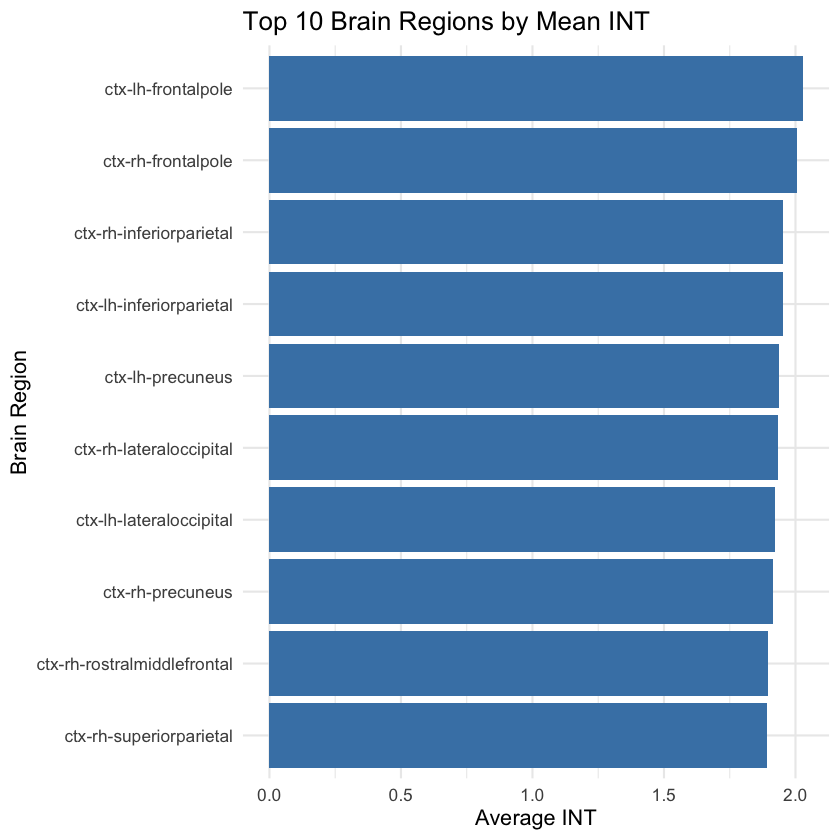

In [40]:
library(ggplot2)

ggplot(
  head(region_mean_INT,10),
  aes(x = reorder(Region, Mean_INT),
      y = Mean_INT)
) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Top 10 Brain Regions by Mean INT",
    x = "Brain Region",
    y = "Average INT"
  ) +
  theme_minimal(base_size = 13)

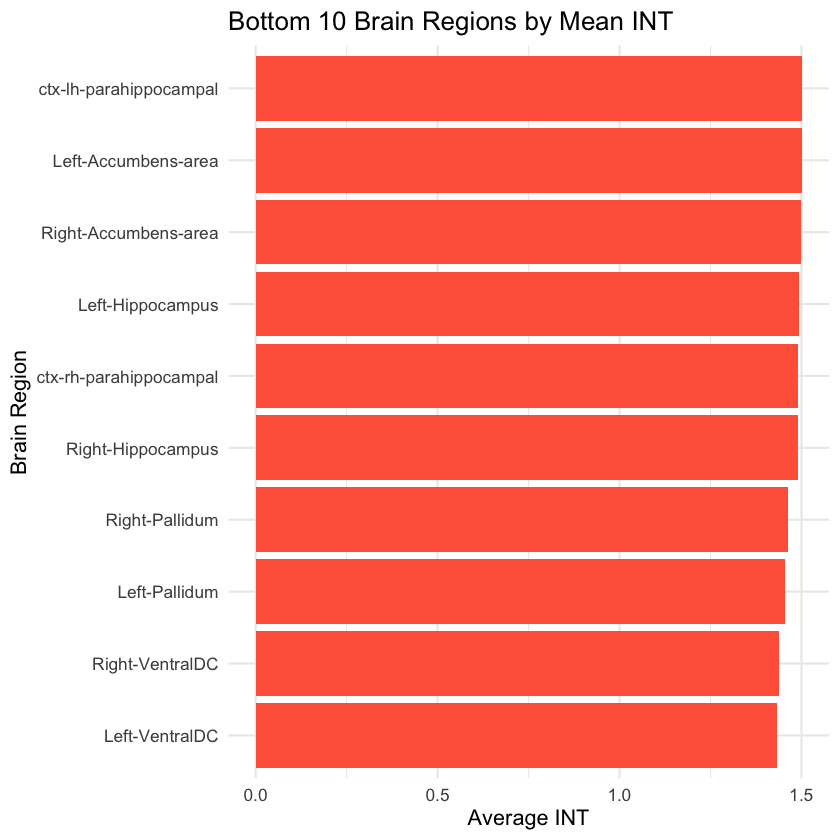

In [42]:
ggplot(
  tail(region_mean_INT,10),
  aes(x = reorder(Region, Mean_INT),
      y = Mean_INT)
) +
  geom_col(fill = "tomato") +
  coord_flip() +
  labs(
    title = "Bottom 10 Brain Regions by Mean INT",
    x = "Brain Region",
    y = "Average INT"
  ) +
  theme_minimal(base_size = 13)

In [43]:
# ============================================================
# Step 12d: Region variability
# ============================================================

region_sd_INT <- data.frame(
  Region = rownames(intmap_combat),
  SD_INT = apply(intmap_combat, 1, sd, na.rm = TRUE)
)

region_sd_INT <-
  region_sd_INT %>%
  arrange(desc(SD_INT))

head(region_sd_INT,10)

,Region,SD_INT
,<chr>,<dbl>
ctx-lh-frontalpole,ctx-lh-frontalpole,0.4158529
ctx-rh-frontalpole,ctx-rh-frontalpole,0.3989856
ctx-rh-pericalcarine,ctx-rh-pericalcarine,0.3306350
ctx-lh-pericalcarine,ctx-lh-pericalcarine,0.3213925
ctx-rh-bankssts,ctx-rh-bankssts,0.2865672
ctx-lh-cuneus,ctx-lh-cuneus,0.2848872
ctx-rh-cuneus,ctx-rh-cuneus,0.2813504
ctx-lh-bankssts,ctx-lh-bankssts,0.2809013
ctx-lh-lateraloccipital,ctx-lh-lateraloccipital,0.2719793


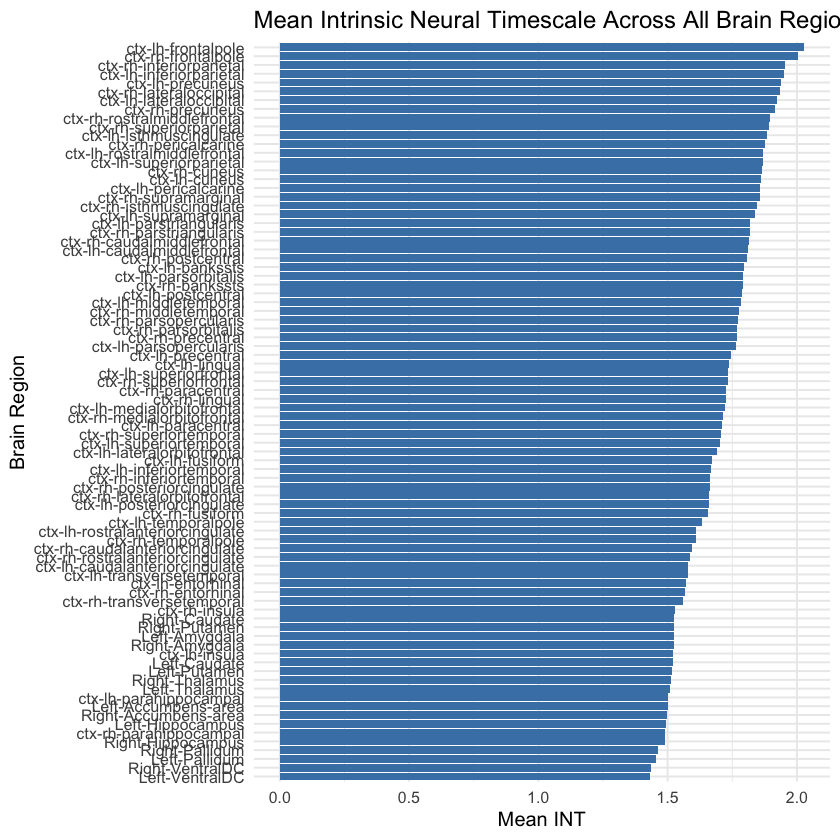

In [44]:
region_mean_INT_plot <- region_mean_INT %>%
  mutate(
    Region = factor(
      Region,
      levels = Region[order(Mean_INT)]
    )
  )

ggplot(region_mean_INT_plot,
       aes(x = Region,
           y = Mean_INT)) +

    geom_col(fill = "steelblue") +

    coord_flip() +

    labs(
      title = "Mean Intrinsic Neural Timescale Across All Brain Regions",
      x = "Brain Region",
      y = "Mean INT"
    ) +

    theme_minimal(base_size = 12)

### Step 12 Summary

Region-level exploratory analysis revealed substantial variation in intrinsic neural timescale (INT) across the brain.

Key observations include:

- The frontal pole exhibited the highest average INT values, followed by association cortical regions including the inferior parietal cortex, precuneus, lateral occipital cortex, and rostral middle frontal cortex.
- Several subcortical and medial temporal regions, including the ventral diencephalon, pallidum, hippocampus, parahippocampal cortex, and nucleus accumbens, exhibited the lowest average INT values.
- The frontal pole also demonstrated the greatest variability across participants, suggesting that this region may contain substantial inter-individual differences.
- Overall, these findings indicate that intrinsic neural timescales vary considerably across anatomical regions, providing a useful baseline for future analyses comparing diagnostic groups (CN, MCI, Converter, and AD).

In [45]:
# ============================================================
# Clean ROI names for plotting
# ============================================================

region_mean_INT_plot <- region_mean_INT

region_mean_INT_plot$Region <-
  region_mean_INT_plot$Region |>
  gsub("^ctx-lh-", "Left ", x = _) |>
  gsub("^ctx-rh-", "Right ", x = _) |>
  gsub("-", " ", x = _)